In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import torch 
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets,transforms
from torch.utils.data import DataLoader,random_split,Subset
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns

In [3]:
class ResidualBlock(nn.Module):
    def __init__(self,input_channels,output_channels,stride=1):
        super().__init__()
        self.conv1=nn.Conv2d(input_channels,output_channels,3,stride=stride,padding=1)
        self.bn1=nn.BatchNorm2d(output_channels)
        self.conv2=nn.Conv2d(output_channels,output_channels,3,stride=1,padding=1)
        self.bn2=nn.BatchNorm2d(output_channels)
        self.relu=nn.ReLU()

        #shortcut
        self.shortcut=nn.Sequential()
        if stride!=1 or input_channels!=output_channels:
            self.shortcut=nn.Sequential(
                nn.Conv2d(input_channels,output_channels,1,stride=stride),
                nn.BatchNorm2d(output_channels)
            )

    def forward(self,x):
        out=self.relu(self.bn1(self.conv1(x)))
        out=self.bn2(self.conv2(out))
        out+=self.shortcut(x)
        out=self.relu(out)
        return out

block=ResidualBlock(64,128,stride=2)
x=torch.randn(4,64,32,32)
out=block(x)
print(out.shape)

torch.Size([4, 128, 16, 16])


In [4]:
class ResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.base=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.stage1=nn.Sequential(
            ResidualBlock(32,32),
            ResidualBlock(32,32)
        )
        self.stage2=nn.Sequential(
            ResidualBlock(32,64,stride=2),
            ResidualBlock(64,64),
            ResidualBlock(64,64)
        )
        self.stage3=nn.Sequential(
            ResidualBlock(64,128,stride=2),
            ResidualBlock(128,128),
            ResidualBlock(128,128)
        )
        self.avgpool=nn.AdaptiveAvgPool2d(1)
        self.fc=nn.Linear(128,10)

    def forward(self,x):
        x=self.base(x)
        x=self.stage1(x)
        x=self.stage2(x)
        x=self.stage3(x)
        x=self.avgpool(x)
        x=x.view(x.size(0),-1)
        x=self.fc(x)
        return x

model=ResNet()
x=torch.randn(4,3,32,32)
print(model(x).shape)

torch.Size([4, 10])


In [5]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data_aug = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
train_data_clean = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

indices = list(range(50000))
train_idx, val_idx = indices[:40000], indices[40000:]

train_set = Subset(train_data_aug, train_idx)    
val_set = Subset(train_data_clean, val_idx)      

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)

test_data=datasets.CIFAR10(root='./data',train=False,download=True,transform=transform)
test_loader=DataLoader(test_data,batch_size=64,shuffle=False)

print(f'Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_data)}')

100%|██████████| 170M/170M [1:01:35<00:00, 46.1kB/s]


Train: 40000, Val: 10000, Test: 10000


In [6]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=20)
num_epochs=20
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    batchloss=0
    for images,labels in train_loader:
        
        optimizer.zero_grad()
        
        labels_pred=model(images)
        
        l=criterion(labels_pred,labels)
        
        l.backward()
        
        optimizer.step()
        
        batchloss+=l.item()
        
    
    model.eval()
    val_loss=0
    correct=0
    total=0

    with torch.no_grad():
        for images,labels in val_loader:
            
            labels_pred=model(images)

            val_loss+=criterion(labels_pred,labels).item()

            predicted=torch.argmax(labels_pred,dim=1)

            correct+=(predicted==labels).sum().item()
            
            total+=labels.size(0)

    scheduler.step()

    batchloss/=len(train_loader)
    train_losses.append(batchloss)
    val_losses.append((val_loss/len(val_loader))) 
    val_accuracies.append((correct/total)*100)
    print(f'Epoch {epoch+1}/{num_epochs} Train Loss: {batchloss:.4f} Val Loss: {val_loss/len(val_loader):.4f} Val Acc: {correct/total*100:.2f}%')

Epoch 1/20 Train Loss: 1.4470 Val Loss: 1.1469 Val Acc: 58.92%
Epoch 2/20 Train Loss: 0.9940 Val Loss: 0.8444 Val Acc: 70.42%
Epoch 3/20 Train Loss: 0.8132 Val Loss: 0.8963 Val Acc: 70.57%
Epoch 4/20 Train Loss: 0.6958 Val Loss: 0.8070 Val Acc: 72.55%
Epoch 5/20 Train Loss: 0.6207 Val Loss: 0.6224 Val Acc: 78.35%
Epoch 6/20 Train Loss: 0.5528 Val Loss: 0.5593 Val Acc: 81.00%
Epoch 7/20 Train Loss: 0.5048 Val Loss: 0.5131 Val Acc: 82.79%
Epoch 8/20 Train Loss: 0.4634 Val Loss: 0.5356 Val Acc: 81.72%
Epoch 9/20 Train Loss: 0.4231 Val Loss: 0.4977 Val Acc: 83.45%
Epoch 10/20 Train Loss: 0.3878 Val Loss: 0.4251 Val Acc: 85.63%
Epoch 11/20 Train Loss: 0.3501 Val Loss: 0.4517 Val Acc: 85.36%
Epoch 12/20 Train Loss: 0.3254 Val Loss: 0.4144 Val Acc: 86.45%
Epoch 13/20 Train Loss: 0.2944 Val Loss: 0.4026 Val Acc: 86.59%
Epoch 14/20 Train Loss: 0.2698 Val Loss: 0.3612 Val Acc: 87.93%
Epoch 15/20 Train Loss: 0.2429 Val Loss: 0.3551 Val Acc: 88.05%
Epoch 16/20 Train Loss: 0.2175 Val Loss: 0.3460 V

In [7]:
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

model.eval()
all_preds=[]
all_labels=[]

with torch.no_grad():
    for images,labels in test_loader:
        outputs=model(images)
        predicted=torch.argmax(outputs,dim=1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds,target_names=classes))

              precision    recall  f1-score   support

    airplane       0.90      0.89      0.89      1000
  automobile       0.94      0.95      0.95      1000
        bird       0.81      0.87      0.84      1000
         cat       0.79      0.75      0.77      1000
        deer       0.87      0.88      0.88      1000
         dog       0.84      0.82      0.83      1000
        frog       0.90      0.92      0.91      1000
       horse       0.94      0.90      0.92      1000
        ship       0.93      0.95      0.94      1000
       truck       0.94      0.93      0.93      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



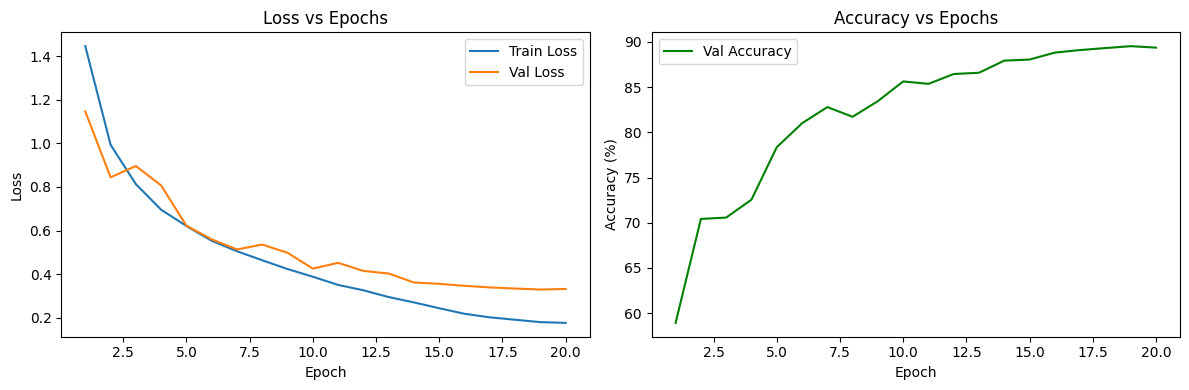

In [8]:
epochs = range(1, num_epochs+1)
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Epochs')
plt.legend()

plt.tight_layout()
plt.savefig('plots.png')
plt.show()

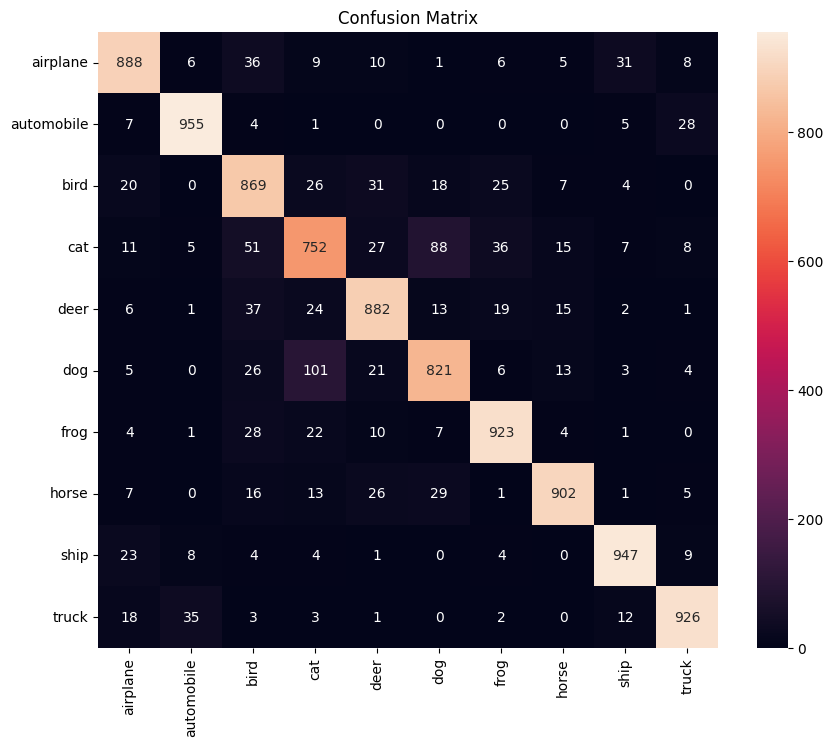

In [9]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')

In [10]:
torch.save(model.state_dict(), 'resnet_cifar10.pth')

-----------

## Architecture Choices

**3 Stages (32→64→128 channels):** Increasing channel depth allows the network to learn 
progressively more complex features — edges in stage 1, patterns in stage 2, 
semantic features in stage 3. Kept to 3 stages (not 4) to balance depth vs. 
training time on CPU.

**Stride=2 at stage transitions:** Downsamples spatial dimensions while increasing 
channels, reducing compute while preserving information through the channel expansion.

**1x1 Conv projections in shortcuts:** When input/output dimensions differ at stage 
boundaries, a 1x1 conv + BN on the skip path matches shapes for the residual addition.

**Global Average Pooling:** Replaces large FC layers with a single spatial average per 
channel map, drastically reducing parameters and overfitting risk before the final 
10-class classifier.

**CosineAnnealingLR + Data Augmentation:** Scheduler smoothly decays LR preventing 
sharp loss spikes. RandomHorizontalFlip + RandomCrop regularize training, 
pushing test accuracy from 83% → 89%.

---------

## DISCUSS
**Why residual connections help optimization**
Deep networks suffer from vanishing gradients — as gradients propagate backwards through many layers, repeated multiplication by small values shrinks them to near zero, making early layers learn extremely slowly or not at all. Residual connections solve this by adding a direct shortcut path (out += shortcut(x)) that carries gradients back to earlier layers without passing through the conv-BN stack. This means even in a deep network, early layers always receive a meaningful gradient signal.

**How skip connections improve gradient flow**
During backpropagation, the gradient of the loss with respect to an earlier layer gets two additive terms — one through the main conv path, one directly through the skip connection. Even if the conv path's gradient vanishes, the skip path contributes directly. This is visible in our training curves — loss decreases steadily across all 20 epochs without plateauing early, which is characteristic of healthy gradient flow throughout the network.

**Effect of network depth on performance**
Our 3-stage architecture (32→64→128 channels) learns increasingly abstract representations: stage 1 captures low-level edges and textures, stage 2 captures mid-level patterns, stage 3 captures high-level semantic features. This hierarchy is what enables 89% accuracy on CIFAR-10 — a plain CNN of comparable parameter count would plateau lower because it can't build this hierarchical representation effectively without residual connections stabilizing training.

**Challenges encountered**
Dimension mismatches at stage transitions (stride=2 + channel increase) required 1×1 conv projections in the shortcut path to match shapes before addition. Without data augmentation (RandomHorizontalFlip + RandomCrop), the model overfit heavily — val loss spiked after epoch 11 while train loss continued dropping. Adding augmentation and a CosineAnnealingLR scheduler resolved this, pushing test accuracy from 83% to 89%.